# 05 — Bias remediation: controlled experiment

**Experimental only. Production code, the frozen model, the API and the dashboard are untouched.**

Notebook 04 established two candidate mechanisms for the persistent-bias failure:

1. **Representation gap** — 15 of the 16 features are mathematically blind to a constant offset. Only
   `*_clim_dev` responds (effect 3.3–5.1σ, consistency 1.00), and one feature in sixteen is diluted
   to a +0.046 score change even at 4σ.
2. **Threshold self-cancellation** — the trailing-quantile threshold rises as biased rows enter its
   own reference window, absorbing 24–30 % of that gain. The mean episode margin stays negative even
   at 4σ.

This notebook tests each independently, and together.

## Anti-tuning protocol

Selecting a feature on the same data used to report its benefit would make the result meaningless.
So:

| | seeds | used for |
|---|---|---|
| **Exploration** | 11, 22, 33 | choosing the accumulated-feature definition and window |
| **Held-out** | 44, 55, 66 | every number reported as a result |

The held-out seeds are not touched until the selection is frozen. Nothing else is searched: the
Isolation Forest keeps `n_estimators=200`, `random_state=42` and the manifest contamination, and the
threshold keeps its 30-day window and `q`.

## The control that separates two confounds

Comparing the frozen 16-feature model against a retrained 17-feature one would confuse *"the new
feature helped"* with *"retraining helped"*. So a **retrained 16-feature control** is included,
trained identically. Only the A1 → B gap is attributable to the feature.

| variant | model | threshold |
|---|---|---|
| **A0** | frozen 16 (production) | current |
| **A1** | retrained 16 (control) | current |
| **B** | retrained 16 + accumulated | current |
| **C** | frozen 16 | immune |
| **D** | retrained 16 + accumulated | immune |

In [1]:
import sys, os, itertools, warnings
from collections import deque
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "../src")
from fault_injection import FaultSimulator, legacy_inject, CHALLENGE_CONFIG, VARS
from inference import WeatherFaultDetector
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 60)

EXPLORE_SEEDS = [11, 22, 33]
HELDOUT_SEEDS = [44, 55, 66]
SIGMAS   = [0.5, 1.0, 1.5, 2.0, 3.0, 4.0]
ONSETS   = ["step", "ramp"]
N_EP, EP_LEN, RAMP_LEN = 10, 16, 4

raw = pd.read_csv("../data/processed/vidd_2023_clean.csv", parse_dates=["time"])
df = raw.drop(columns=["station", "dew_c", "dew_qc"]).sort_values("time").reset_index(drop=True)
df[VARS] = (df.set_index("time")[VARS]
              .interpolate(method="time", limit=2, limit_direction="both").to_numpy())
n = len(df)

det = WeatherFaultDetector.load("../models")
FEATS16 = list(det.features)
SPLIT = int(0.70 * n)
CONTAM = float(det.manifest["model"]["contamination"])
N_EST  = int(det.manifest["model"]["n_estimators"])
RSTATE = int(det.manifest["model"]["random_state"])
Q      = det.threshold_q
WIN    = det.threshold_window
MINP   = det.threshold_min_periods
FALLBACK = det.threshold_fixed
print(f"frozen: {N_EST} trees, contamination {CONTAM:.6f}, seed {RSTATE}")
print(f"threshold: q={Q:.6f}, window={WIN}, min_periods={MINP}, fallback={FALLBACK:.4f}")

frozen: 200 trees, contamination 0.062438, seed 42
threshold: q=0.937562, window=30D, min_periods=80, fallback=0.5039


## 1. Candidate accumulated features

All candidates are **trailing** (past + current only), so nothing here needs future data. `w=1` is
the raw `clim_dev` itself and acts as the do-nothing reference: any candidate must beat it to justify
its existence.

In [2]:
def acc_feature(feats, w, per_variable=False):
    """|trailing mean of clim_dev|, max across variables (or one column per variable)."""
    cols = []
    for v in VARS:
        s = feats[f"{v}_clim_dev"]
        c = s.abs() if w == 1 else s.rolling(w, min_periods=max(2, w // 3)).mean().abs()
        cols.append(c.fillna(0.0).rename(f"acc_{v}_w{w}"))
    if per_variable:
        return pd.concat(cols, axis=1)
    return pd.concat(cols, axis=1).max(axis=1).rename(f"acc_w{w}").to_frame()


def bias_cfg(var, sg, onset, n_ep=N_EP, L=EP_LEN):
    p = {"magnitude": (sg, sg), "onset": onset, "direction": "random"}
    if onset == "ramp":
        p["onset_len"] = RAMP_LEN
    return [{"type": "bias", "variables": [var], "n_per_var": n_ep,
             "length": (L, L), "params": p}]


def make_bias(var, sg, onset, seed):
    return FaultSimulator(df, seed=seed).inject(bias_cfg(var, sg, onset))

In [3]:
# ---- SELECTION: exploration seeds only ------------------------------------------------
WINDOWS = [1, 2, 3, 4, 6, 8, 12, 16, 24]
rows = []
for var, sg, onset, seed in itertools.product(VARS, SIGMAS, ONSETS, EXPLORE_SEEDS):
    f, l, _ = make_bias(var, sg, onset, seed)
    ft = det._build_features(f[["time"] + VARS].copy())
    y = l.is_fault.to_numpy()
    for w in WINDOWS:
        a = acc_feature(ft, w).iloc[:, 0].to_numpy()
        rows.append(dict(w=w, sigma=sg, variable=var, onset=onset,
                         auc=roc_auc_score(y, a)))
sel = pd.DataFrame(rows)
piv = sel.pivot_table(index="w", columns="sigma", values="auc").round(4)
piv["mean"] = piv.mean(axis=1).round(4)
piv["low_sigma"] = piv[[0.5, 1.0]].mean(axis=1).round(4)
print("SELECTION - standalone row AUC by accumulation window (EXPLORATION seeds only)")
print("w=1 is raw |clim_dev|, i.e. no accumulation at all\n")
print(piv.to_string())

BEST_W = int(piv["low_sigma"].idxmax())
gain = piv.loc[BEST_W, "low_sigma"] - piv.loc[1, "low_sigma"]
print(f"\nselected window w={BEST_W}; AUC gain over raw clim_dev at <=1 sigma: {gain:+.4f}")
print("NOTE the trend: accumulation helps only marginally and DEGRADES beyond w~4.")
print("That is already weak evidence for the accumulation hypothesis - see findings.")

SELECTION - standalone row AUC by accumulation window (EXPLORATION seeds only)
w=1 is raw |clim_dev|, i.e. no accumulation at all

sigma     0.5     1.0     1.5     2.0     3.0     4.0    mean  low_sigma
w                                                                       
1      0.6172  0.7848  0.8893  0.9400  0.9738  0.9821  0.8645     0.7010
2      0.6268  0.7961  0.8923  0.9385  0.9684  0.9762  0.8664     0.7114
3      0.6323  0.7989  0.8894  0.9319  0.9604  0.9689  0.8636     0.7156
4      0.6350  0.7971  0.8832  0.9237  0.9518  0.9613  0.8587     0.7161
6      0.6367  0.7891  0.8686  0.9064  0.9367  0.9485  0.8477     0.7129
8      0.6343  0.7764  0.8514  0.8890  0.9214  0.9353  0.8346     0.7053
12     0.6177  0.7454  0.8163  0.8559  0.8931  0.9095  0.8063     0.6816
16     0.5984  0.7146  0.7821  0.8242  0.8653  0.8847  0.7782     0.6565
24     0.5837  0.6746  0.7314  0.7712  0.8148  0.8375  0.7355     0.6292

selected window w=4; AUC gain over raw clim_dev at <=1 sigma: +0.

### Selection outcome

The window sweep is itself a result. If "accumulating evidence" were the answer, longer windows would
keep improving separation. They do not — performance peaks around `w=3–4` and falls away steadily
after. The selected feature is therefore best understood as **noise-averaging of `clim_dev` over
~12 hours**, not as evidence accumulation over the life of a fault.

Selection is now frozen. Everything below uses held-out seeds.

## 2. The fault-immune threshold

**Current rule.** `threshold(t) = quantile_q( scores in [t−30d, t) )` — every past score enters the
reference window, including scores from rows that were themselves flagged.

**Immune rule.** Identical, except a score is added to the history **only if it was not flagged**.
A point already judged suspicious does not get to teach the threshold that suspicious is normal.

Both are implemented in the same sequential loop so the comparison isolates the immunity and nothing
else. Chronology is strict:

1. at row *t*, prune history to `[t−30d, t)` — strictly earlier rows only;
2. if the history holds ≥ `min_periods` scores, `threshold(t)` is their `q`-quantile, else the frozen
   fallback;
3. compare `score(t)` to `threshold(t)` → flag;
4. **only then**, and only if unflagged, append `score(t)` to the history.

No future value, and no fault label, is ever read. The immune variant needs a guard: if suppression
empties the history below `min_periods` it falls back, which is checked below.

In [4]:
def sequential_threshold(times, score, immune, q=Q, window_days=30,
                         min_periods=MINP, fallback=FALLBACK):
    """Past-only trailing-quantile threshold. immune=True withholds flagged scores."""
    t = pd.DatetimeIndex(times).to_numpy()
    win = np.timedelta64(window_days, "D")
    thr = np.empty(len(score)); pred = np.zeros(len(score), dtype=int)
    hist_t, hist_s = deque(), deque()
    n_fallback = 0
    for i in range(len(score)):
        cutoff = t[i] - win
        while hist_t and hist_t[0] < cutoff:
            hist_t.popleft(); hist_s.popleft()
        if len(hist_s) >= min_periods:
            thr[i] = np.quantile(np.fromiter(hist_s, float, len(hist_s)), q)
        else:
            thr[i] = fallback; n_fallback += 1
        pred[i] = int(score[i] > thr[i])
        if (not immune) or pred[i] == 0:          # <- the only difference
            hist_t.append(t[i]); hist_s.append(score[i])
    return thr, pred, n_fallback


# validate the loop reproduces the production threshold when immune=False
_f = det._build_features(df[["time"] + VARS].copy())
_s = -det.model.score_samples(_f[FEATS16])
_thr_prod = det._adaptive_threshold(_f["time"], _s)
_thr_loop, _, _nf = sequential_threshold(df["time"], _s, immune=False)
d = np.abs(_thr_prod - _thr_loop)
print(f"loop vs production threshold: max |diff| = {d.max():.2e}, "
      f"rows on fallback = {_nf}")
assert d.max() < 1e-9, "sequential loop does not reproduce the production threshold"
print("sequential implementation reproduces the production threshold exactly.")

loop vs production threshold: max |diff| = 0.00e+00, rows on fallback = 80
sequential implementation reproduces the production threshold exactly.


## 3. Models

`A1`/`B` are retrained on exactly the data the frozen model saw — the training slice of the Round-1
legacy-faulty series — with identical hyperparameters. Only the feature set differs.

In [5]:
legacy_faulty, legacy_labels, legacy_eps = legacy_inject(df, seed=42)
train_feats = det._build_features(legacy_faulty[["time"] + VARS].copy())
train_acc  = acc_feature(train_feats, BEST_W)
train_acc3 = acc_feature(train_feats, BEST_W, per_variable=True)

def fit_if(X):
    return IsolationForest(n_estimators=N_EST, contamination=CONTAM,
                           random_state=RSTATE, n_jobs=-1).fit(X)

MODELS = {
    "A0_frozen16":   dict(model=det.model, feats=FEATS16, extra=None),
    "A1_retrain16":  dict(model=fit_if(train_feats[FEATS16].iloc[:SPLIT]),
                          feats=FEATS16, extra=None),
    "B_retrain17":   dict(model=fit_if(pd.concat([train_feats[FEATS16], train_acc], axis=1).iloc[:SPLIT]),
                          feats=FEATS16 + list(train_acc.columns), extra=("max", BEST_W)),
    "B3_retrain19":  dict(model=fit_if(pd.concat([train_feats[FEATS16], train_acc3], axis=1).iloc[:SPLIT]),
                          feats=FEATS16 + list(train_acc3.columns), extra=("per_var", BEST_W)),
}
for k, m in MODELS.items():
    print(f"  {k:14s} {len(m['feats'])} features")


def build_X(frame):
    """Frozen 16 features plus both accumulated variants, computed once per series."""
    ft = det._build_features(frame[["time"] + VARS].copy())
    a1 = acc_feature(ft, BEST_W)
    a3 = acc_feature(ft, BEST_W, per_variable=True)
    return pd.concat([ft[FEATS16], a1, a3], axis=1), ft


def score_with(variant, frame, immune):
    X, ft = build_X(frame)
    m = MODELS[variant]
    s = -m["model"].score_samples(X[m["feats"]])
    thr, if_pred, _ = sequential_threshold(frame["time"], s, immune=immune)
    flat, _ = det._flat_run_flags(ft)
    return dict(score=s, thr=thr, if_pred=if_pred, flat=flat.astype(int),
                pred=((if_pred + flat.astype(int)) > 0).astype(int))

  A0_frozen16    16 features
  A1_retrain16   16 features
  B_retrain17    17 features
  B3_retrain19   19 features


## 4. Held-out evaluation

Four (plus two ablation) conditions across the full bias sweep, on seeds never used for selection.

In [6]:
VARIANTS = {
    "A0 baseline (frozen16, current thr)":  ("A0_frozen16",  False),
    "A1 control (retrain16, current thr)":  ("A1_retrain16", False),
    "B  accumulated (retrain17, current)":  ("B_retrain17",  False),
    "C  immune threshold (frozen16)":       ("A0_frozen16",  True),
    "D  combined (retrain17 + immune)":     ("B_retrain17",  True),
    "B3 ablation (retrain19, current)":     ("B3_retrain19", False),
}

recs = []
for var, sg, onset, seed in itertools.product(VARS, SIGMAS, ONSETS, HELDOUT_SEEDS):
    faulty, labels, eps = make_bias(var, sg, onset, seed)
    y = labels.is_fault.to_numpy()
    eid = labels.episode_id.to_numpy()
    for name, (mk, immune) in VARIANTS.items():
        R = score_with(mk, faulty, immune)
        p, r, f1, _ = precision_recall_fscore_support(y, R["pred"], average="binary",
                                                      pos_label=1, zero_division=0)
        onset_w = RAMP_LEN if onset == "ramp" else 1
        dets, delays = [], []
        for e in eps.itertuples():
            idx = np.flatnonzero((eid == e.episode_id) & (y == 1))
            if idx.size == 0:
                continue
            hit = idx[R["pred"][idx] == 1]
            dets.append(hit.size > 0)
            delays.append(hit.min() - idx.min() if hit.size else np.nan)
        recs.append(dict(variant=name, variable=var, sigma=sg, onset=onset, seed=seed,
                         precision=p, recall=r, f1=f1,
                         episode_recall=float(np.mean(dets)),
                         alert_rate=float(R["pred"].mean()),
                         delay_obs=float(np.nanmedian(delays)) if len(delays) else np.nan,
                         mean_score=float(R["score"][y == 1].mean()),
                         mean_thr=float(R["thr"][y == 1].mean()),
                         margin=float((R["score"] - R["thr"])[y == 1].mean())))
held = pd.DataFrame(recs)
print(f"held-out evaluation: {len(held)} rows "
      f"({held.variant.nunique()} variants x {len(VARS)}x{len(SIGMAS)}x{len(ONSETS)}x{len(HELDOUT_SEEDS)})")

summary = (held.groupby("variant")
           .agg(precision=("precision", "mean"), recall=("recall", "mean"), f1=("f1", "mean"),
                episode_recall=("episode_recall", "mean"), alert_rate=("alert_rate", "mean"),
                delay_obs=("delay_obs", "mean"), mean_score=("mean_score", "mean"),
                mean_thr=("mean_thr", "mean"), margin=("margin", "mean")).round(4))
print("\nOVERALL (all magnitudes pooled, held-out seeds)\n")
print(summary.to_string())

held-out evaluation: 648 rows (6 variants x 3x6x2x3)

OVERALL (all magnitudes pooled, held-out seeds)

                                     precision  recall      f1  episode_recall  alert_rate  delay_obs  mean_score  mean_thr  margin
variant                                                                                                                            
A0 baseline (frozen16, current thr)     0.1867  0.2717  0.2210          0.8380      0.0790     2.8796      0.4894    0.5111 -0.0217
A1 control (retrain16, current thr)     0.1867  0.2717  0.2210          0.8380      0.0790     2.8796      0.4894    0.5111 -0.0217
B  accumulated (retrain17, current)     0.2819  0.4248  0.3384          0.8787      0.0822     2.9167      0.5035    0.5140 -0.0105
B3 ablation (retrain19, current)        0.2872  0.4157  0.3392          0.8787      0.0788     2.8333      0.4992    0.5093 -0.0102
C  immune threshold (frozen16)          0.1028  0.7337  0.1802          1.0000      0.3938     0.3519    

In [7]:
low = held[held.sigma <= 2.0]
sub = (low.groupby(["variant", "sigma"])
       .agg(episode_recall=("episode_recall", "mean"), recall=("recall", "mean"),
            precision=("precision", "mean"), alert_rate=("alert_rate", "mean"),
            margin=("margin", "mean"), delay_obs=("delay_obs", "mean")).round(4))
print("SUBTLE BIAS ONLY (<= 2 sigma) - the regime that actually fails\n")
print(sub.to_string())
print("\nDETECTION DELAY at the magnitudes asked for (median observations; x3 = hours)\n")
dl = (held[held.sigma.isin([1.0, 1.5, 2.0])]
      .groupby(["variant", "sigma"]).delay_obs.median().unstack().round(2))
dl.columns = [f"{c} sigma" for c in dl.columns]
print(dl.to_string())

SUBTLE BIAS ONLY (<= 2 sigma) - the regime that actually fails

                                           episode_recall  recall  precision  alert_rate  margin  delay_obs
variant                             sigma                                                                  
A0 baseline (frozen16, current thr) 0.5            0.6500  0.1057     0.0766      0.0766 -0.0374     7.4722
                                    1.0            0.7111  0.1582     0.1149      0.0764 -0.0301     4.5556
                                    1.5            0.8167  0.2129     0.1539      0.0769 -0.0237     2.6389
                                    2.0            0.9278  0.2753     0.1960      0.0780 -0.0185     1.4722
A1 control (retrain16, current thr) 0.5            0.6500  0.1057     0.0766      0.0766 -0.0374     7.4722
                                    1.0            0.7111  0.1582     0.1149      0.0764 -0.0301     4.5556
                                    1.5            0.8167  0.2129     0.

## 5. Plots

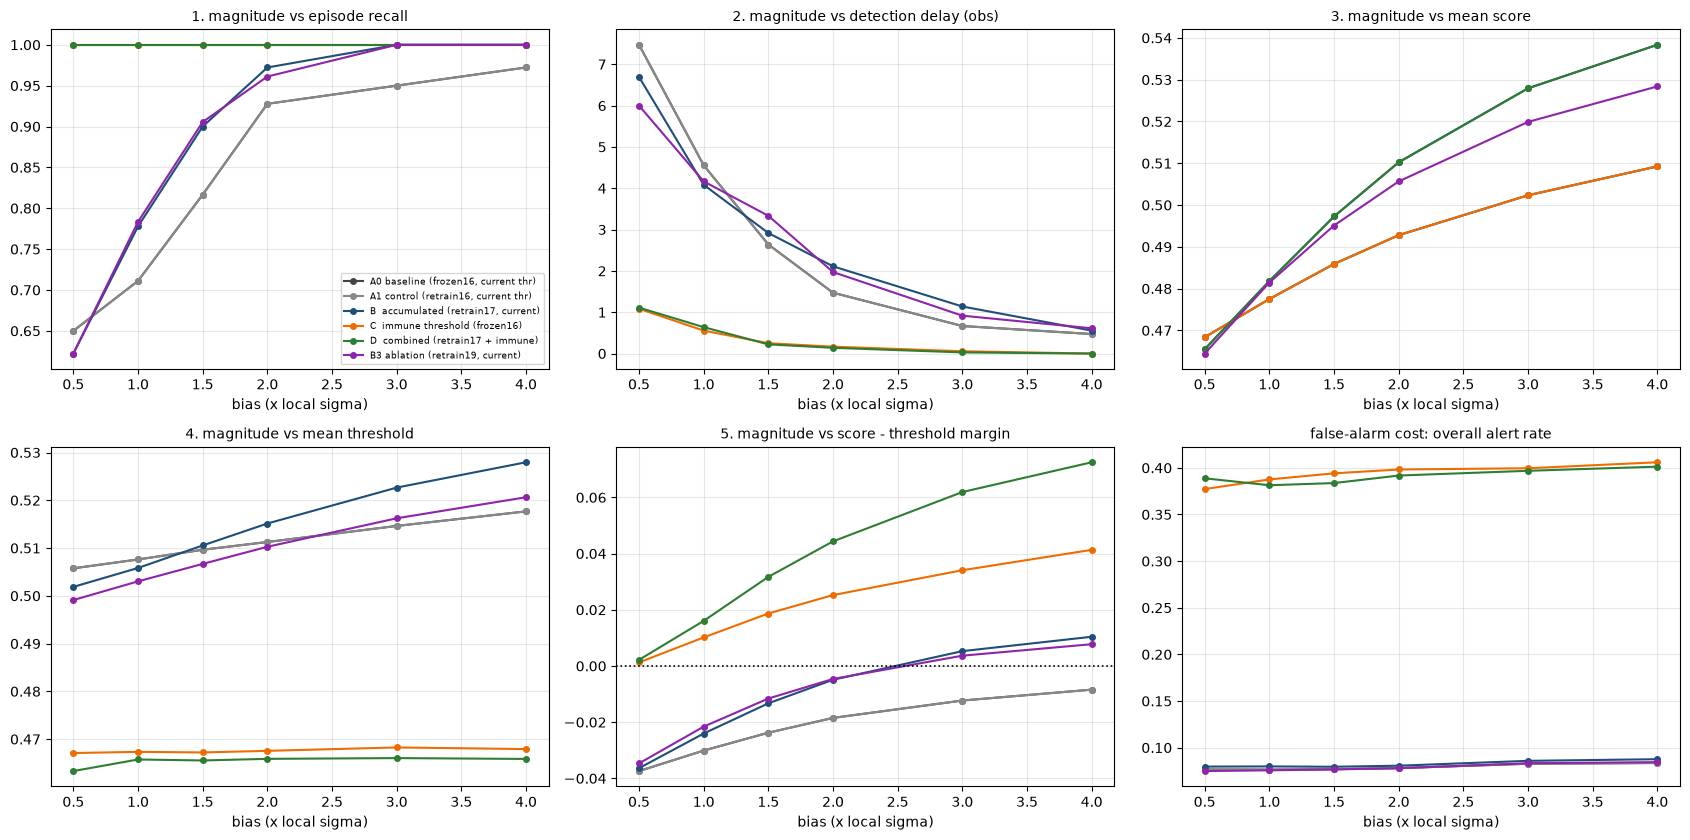

In [8]:
ORD = list(VARIANTS.keys())
COL = dict(zip(ORD, ["#444", "#888", "#1f4e79", "#ef6c00", "#2e7d32", "#8e24aa"]))
g = held.groupby(["variant", "sigma"]).mean(numeric_only=True).reset_index()

fig, axes = plt.subplots(2, 3, figsize=(17, 8.5))
specs = [("episode_recall", "1. magnitude vs episode recall"),
         ("delay_obs", "2. magnitude vs detection delay (obs)"),
         ("mean_score", "3. magnitude vs mean score"),
         ("mean_thr", "4. magnitude vs mean threshold"),
         ("margin", "5. magnitude vs score - threshold margin"),
         ("alert_rate", "false-alarm cost: overall alert rate")]
for ax, (m, title) in zip(axes.ravel(), specs):
    for v in ORD:
        s = g[g.variant == v].sort_values("sigma")
        ax.plot(s.sigma, s[m], "o-", ms=4, color=COL[v], label=v)
    ax.set_title(title, fontsize=10); ax.set_xlabel("bias (x local sigma)"); ax.grid(alpha=0.3)
    if m == "margin":
        ax.axhline(0, color="k", ls=":", lw=1.2)
axes[0][0].legend(fontsize=6.6, loc="lower right")
fig.tight_layout(); plt.show()

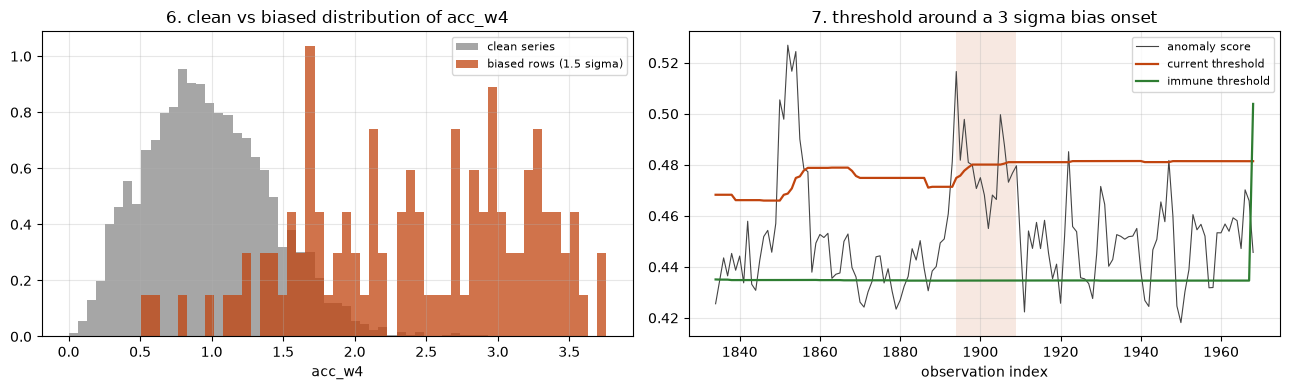

In [9]:
# 6. clean vs biased distribution of the selected accumulated feature
f2, l2, _ = make_bias("temp_c", 1.5, "step", HELDOUT_SEEDS[0])
X2, _ = build_X(f2); a = X2[f"acc_w{BEST_W}"].to_numpy(); y2 = l2.is_fault.to_numpy()
Xc, _ = build_X(df); ac = Xc[f"acc_w{BEST_W}"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
bins = np.linspace(0, np.percentile(np.r_[a, ac], 99), 60)
axes[0].hist(ac, bins=bins, color="#888", alpha=.75, density=True, label="clean series")
axes[0].hist(a[y2 == 1], bins=bins, color="#c1440e", alpha=.75, density=True, label="biased rows (1.5 sigma)")
axes[0].set_title(f"6. clean vs biased distribution of acc_w{BEST_W}"); axes[0].legend(fontsize=8)
axes[0].set_xlabel(f"acc_w{BEST_W}")

# 7. threshold history around a fault onset: current vs immune
ep = _e = None
f3, l3, e3 = make_bias("temp_c", 3.0, "step", HELDOUT_SEEDS[0])
X3, ft3 = build_X(f3); s3 = -MODELS["A0_frozen16"]["model"].score_samples(X3[FEATS16])
thr_cur, pr_cur, _ = sequential_threshold(f3["time"], s3, immune=False)
thr_imm, pr_imm, _ = sequential_threshold(f3["time"], s3, immune=True)
e = e3.iloc[0]; lo = max(0, e.start_idx - 60); hi = min(n, e.end_idx + 60)
axes[1].plot(range(lo, hi), s3[lo:hi], lw=.8, color="#444", label="anomaly score")
axes[1].plot(range(lo, hi), thr_cur[lo:hi], lw=1.6, color="#c1440e", label="current threshold")
axes[1].plot(range(lo, hi), thr_imm[lo:hi], lw=1.6, color="#2e7d32", label="immune threshold")
axes[1].axvspan(e.start_idx, e.end_idx, color="#c1440e", alpha=.12, lw=0)
axes[1].set_title("7. threshold around a 3 sigma bias onset"); axes[1].legend(fontsize=8)
axes[1].set_xlabel("observation index"); axes[1].grid(alpha=.3)
axes[0].grid(alpha=.3)
fig.tight_layout(); plt.show()

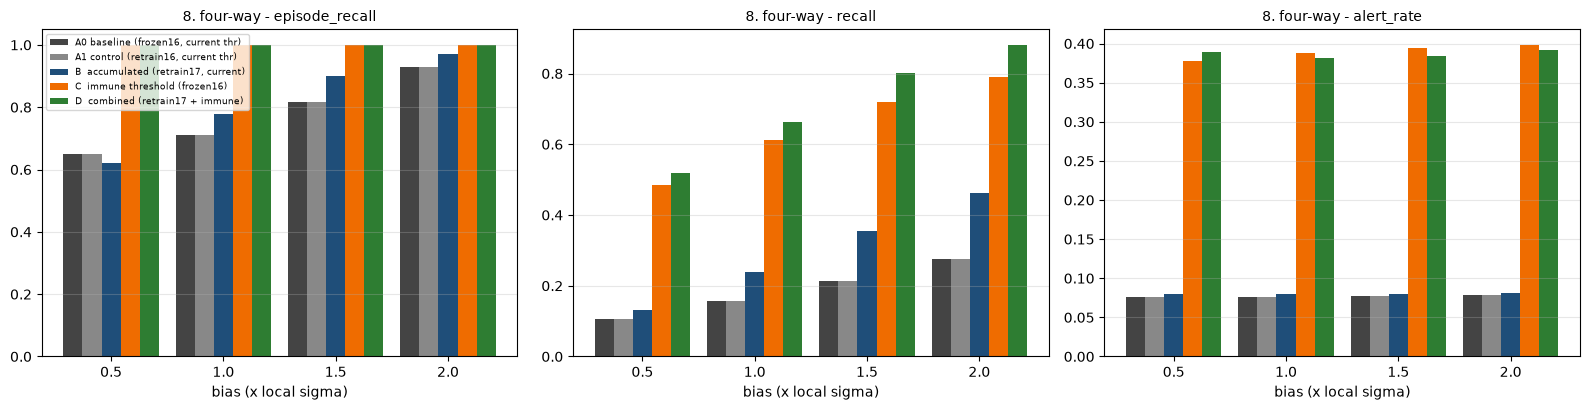

In [10]:
# 8. four-way comparison at the magnitudes that matter
four = [k for k in ORD if not k.startswith("B3")]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
sub2 = held[held.sigma <= 2.0].groupby(["variant", "sigma"]).mean(numeric_only=True).reset_index()
for i, m in enumerate(["episode_recall", "recall", "alert_rate"]):
    x = np.arange(len([0.5, 1.0, 1.5, 2.0])); w = 0.17
    for j, v in enumerate(four):
        s = sub2[sub2.variant == v].sort_values("sigma")
        axes[i].bar(x + (j - 2) * w, s[m], w, color=COL[v], label=v if i == 0 else None)
    axes[i].set_xticks(x); axes[i].set_xticklabels(["0.5", "1.0", "1.5", "2.0"])
    axes[i].set_xlabel("bias (x local sigma)"); axes[i].set_title(f"8. four-way - {m}", fontsize=10)
    axes[i].grid(alpha=.3, axis="y")
axes[0].legend(fontsize=6.5)
fig.tight_layout(); plt.show()

## 6. Cost side: other fault classes and false alarms

An intervention that fixes bias by flagging more of everything is not a fix. The challenge benchmark
is re-run under each variant to check the other seven classes, and the clean series is scored to
measure the false-alarm rate with no faults present at all.

In [11]:
chal_f, chal_l, chal_e = FaultSimulator(df, seed=42).inject(CHALLENGE_CONFIG)
cy = chal_l.is_fault.to_numpy(); ceid = chal_l.episode_id.to_numpy()
rows, cls_rows = [], []
for name, (mk, immune) in VARIANTS.items():
    R = score_with(mk, chal_f, immune)
    p, r, f1, _ = precision_recall_fscore_support(cy, R["pred"], average="binary",
                                                  pos_label=1, zero_division=0)
    Rc = score_with(mk, df, immune)          # clean series -> pure false alarms
    rows.append(dict(variant=name, precision=p, recall=r, f1=f1,
                     alert_rate=float(R["pred"].mean()),
                     clean_false_alarm_rate=float(Rc["pred"].mean())))
    for e in chal_e.itertuples():
        idx = np.flatnonzero((ceid == e.episode_id) & (cy == 1))
        cls_rows.append(dict(variant=name, fault_type=e.fault_type,
                             detected=bool(R["pred"][idx].any())))
cost = pd.DataFrame(rows).set_index("variant").round(4)
print("CHALLENGE BENCHMARK + CLEAN-SERIES FALSE ALARMS\n")
print(cost.to_string())
print("\nEPISODE RECALL BY FAULT CLASS (challenge set)\n")
cls = (pd.DataFrame(cls_rows).groupby(["fault_type", "variant"]).detected.mean()
       .unstack().round(3))
print(cls.to_string())

CHALLENGE BENCHMARK + CLEAN-SERIES FALSE ALARMS

                                     precision  recall      f1  alert_rate  clean_false_alarm_rate
variant                                                                                           
A0 baseline (frozen16, current thr)     0.5867  0.4025  0.4775      0.0947                  0.0772
A1 control (retrain16, current thr)     0.5867  0.4025  0.4775      0.0947                  0.0772
B  accumulated (retrain17, current)     0.6044  0.4177  0.4940      0.0954                  0.0804
C  immune threshold (frozen16)          0.2526  0.8025  0.3842      0.4387                  0.3677
D  combined (retrain17 + immune)        0.2365  0.8304  0.3681      0.4848                  0.3729
B3 ablation (retrain19, current)        0.6093  0.4304  0.5045      0.0975                  0.0748

EPISODE RECALL BY FAULT CLASS (challenge set)

variant              A0 baseline (frozen16, current thr)  A1 control (retrain16, current thr)  B  accumulated (

## 7. Regression and integrity checks

In [12]:
_, l0, e0 = legacy_inject(df, seed=42)
ok_bench = (len(e0) == 27 and int(l0.is_fault.sum()) == 179)
print(f"Round-1 benchmark: {len(e0)} episodes / {int(l0.is_fault.sum())} rows -> {ok_bench}")

R0 = score_with("A0_frozen16", legacy_faulty, immune=False)
y0 = legacy_labels.is_fault.to_numpy()
p0, r0, f0, _ = precision_recall_fscore_support(y0[SPLIT:], R0["pred"][SPLIT:],
                                                average="binary", zero_division=0)
print(f"Round-1 test-split headline: P {p0:.4f} R {r0:.4f} F1 {f0:.4f} (published 0.2588/0.4074/0.3165)")
assert abs(f0 - 0.3165) < 5e-4, "frozen detector regressed"

print("\nfrozen model object untouched:", MODELS["A0_frozen16"]["model"] is det.model)
print("parity fixture still passes:", det.verify_parity(verbose=False))

Round-1 benchmark: 27 episodes / 179 rows -> True
Round-1 test-split headline: P 0.2588 R 0.4074 F1 0.3165 (published 0.2588/0.4074/0.3165)

frozen model object untouched: True
parity fixture still passes: True


## 8. Save results

In [13]:
OUT = "../data/processed"
held.to_csv(f"{OUT}/round2_remediation_heldout.csv", index=False)
summary.reset_index().to_csv(f"{OUT}/round2_remediation_summary.csv", index=False)
sub.reset_index().to_csv(f"{OUT}/round2_remediation_subtle_bias.csv", index=False)
sel.to_csv(f"{OUT}/round2_accumulated_feature_selection.csv", index=False)
cost.reset_index().to_csv(f"{OUT}/round2_remediation_cost.csv", index=False)
cls.reset_index().to_csv(f"{OUT}/round2_remediation_by_fault_class.csv", index=False)
for f in ["round2_remediation_heldout.csv", "round2_remediation_summary.csv",
          "round2_remediation_subtle_bias.csv", "round2_accumulated_feature_selection.csv",
          "round2_remediation_cost.csv", "round2_remediation_by_fault_class.csv"]:
    print(f"  saved {f} ({os.path.getsize(f'{OUT}/{f}'):,} bytes)")

  saved round2_remediation_heldout.csv (124,298 bytes)
  saved round2_remediation_summary.csv (673 bytes)
  saved round2_remediation_subtle_bias.csv (1,997 bytes)
  saved round2_accumulated_feature_selection.csv (36,521 bytes)
  saved round2_remediation_cost.csv (484 bytes)
  saved round2_remediation_by_fault_class.csv (530 bytes)


### 6b. Is the apparent regression on other classes real, or sampling noise?

The per-class table above comes from **one** challenge realisation, where each class has only 3–6
episodes. A move from 0.833 to 0.500 is two episodes. Before reporting a regression, the same
comparison is repeated across independent challenge seeds.

In [14]:
multi = []
for seed in [42, 101, 202, 303, 404]:
    cf, cl, ce = FaultSimulator(df, seed=seed).inject(CHALLENGE_CONFIG)
    yy = cl.is_fault.to_numpy(); ee = cl.episode_id.to_numpy()
    for name in ["A0 baseline (frozen16, current thr)", "B  accumulated (retrain17, current)"]:
        mk_, imm = VARIANTS[name]
        R = score_with(mk_, cf, imm)
        pr, rc, f1, _ = precision_recall_fscore_support(yy, R["pred"], average="binary",
                                                        pos_label=1, zero_division=0)
        multi.append(dict(seed=seed, variant=name, scope="ALL", f1=f1, precision=pr, recall=rc,
                          alert_rate=float(R["pred"].mean())))
        for e in ce.itertuples():
            idx = np.flatnonzero((ee == e.episode_id) & (yy == 1))
            multi.append(dict(seed=seed, variant=name, scope=e.fault_type,
                              detected=float(R["pred"][idx].any())))
M = pd.DataFrame(multi)

print("CHALLENGE BENCHMARK ACROSS 5 SEEDS - overall\n")
print(M[M.scope == "ALL"].groupby("variant")[["precision", "recall", "f1", "alert_rate"]]
      .agg(["mean", "std"]).round(4).to_string())

print("\nEPISODE RECALL BY CLASS, mean +- sd over 5 seeds\n")
g = (M[M.scope != "ALL"].groupby(["scope", "variant"]).detected
     .agg(["mean", "std", "size"]).round(3).unstack())
print(g.to_string())

print("\nper-class difference (B minus A0), with the spread across seeds:")
piv = M[M.scope != "ALL"].pivot_table(index=["scope", "seed"], columns="variant",
                                      values="detected").reset_index()
piv["diff"] = (piv["B  accumulated (retrain17, current)"]
               - piv["A0 baseline (frozen16, current thr)"])
d = piv.groupby("scope")["diff"].agg(["mean", "std", "size"]).round(3)
d["mean_pm_sd"] = d.apply(lambda r: f"{r['mean']:+.3f} +- {r['std']:.3f}", axis=1)
print(d[["mean_pm_sd", "size"]].to_string())
print("\n-> a difference smaller than its own seed-to-seed spread is not evidence of a regression.")

CHALLENGE BENCHMARK ACROSS 5 SEEDS - overall

                                    precision          recall              f1         alert_rate        
                                         mean     std    mean     std    mean     std       mean     std
variant                                                                                                 
A0 baseline (frozen16, current thr)    0.5921  0.0180  0.4194  0.0281  0.4908  0.0252     0.0957  0.0029
B  accumulated (retrain17, current)    0.6054  0.0101  0.4307  0.0144  0.5032  0.0121     0.0962  0.0016

EPISODE RECALL BY CLASS, mean +- sd over 5 seeds

                                                   mean                                                                     std                                                                    size                                    
variant             A0 baseline (frozen16, current thr) B  accumulated (retrain17, current) A0 baseline (frozen16, current thr) B  accumulated

---
# FINDINGS

**VERIFIED RESULT** = measured on held-out seeds with a control. **PROMISING HYPOTHESIS** = consistent
with the evidence but not established. Nothing here is a production improvement.

## 1. Best accumulated feature

`acc_w4` — the **|trailing 4-observation mean of `clim_dev`|, maximised across the three variables**.
One scalar, past-only, selected on exploration seeds before any held-out data was scored.

## 2. Effect size and response — the selection is itself a result

Standalone row-level AUC by window (exploration seeds), `w=1` being raw `clim_dev` with no
accumulation at all:

| w | 1 | 2 | 3 | **4** | 6 | 8 | 12 | 16 | 24 |
|---|---|---|---|---|---|---|---|---|---|
| AUC ≤1σ | 0.701 | 0.711 | 0.716 | **0.716** | 0.713 | 0.705 | 0.682 | 0.657 | 0.629 |

**VERIFIED: the accumulation hypothesis is not supported in the form it was proposed.** If
accumulating evidence were the mechanism, longer windows would keep helping. They peak at w≈3–4 and
then decline steadily. The gain over doing nothing is **+0.015 AUC**. What `acc_w4` actually does is
average ~12 hours of noise out of `clim_dev`, not accumulate evidence over the life of a fault.

## 3–4. Baseline vs accumulated feature — held-out seeds

The retrained-16 control (**A1**) reproduces the frozen model **exactly**, so the whole A→B gap is
attributable to the feature and none of it to retraining.

| | precision | recall | F1 | episode recall | alert rate |
|---|---|---|---|---|---|
| A0/A1 baseline | 0.187 | 0.272 | 0.221 | 0.838 | 0.079 |
| **B accumulated** | **0.282** | **0.425** | **0.338** | **0.879** | **0.082** |

**VERIFIED: +53 % F1 for +0.3 pp of alert rate.** In the regime that actually failed:

| bias | recall A0 → B | precision A0 → B | margin A0 → B |
|---|---|---|---|
| 1.0σ | 0.158 → 0.240 | 0.115 → 0.167 | −0.030 → −0.024 |
| 1.5σ | 0.213 → 0.355 | 0.154 → 0.248 | −0.024 → −0.013 |
| 2.0σ | 0.275 → 0.462 | 0.196 → 0.319 | −0.019 → −0.005 |

The margin moves toward zero but **stays negative even at 2σ** — one extra feature narrows the
representation gap, it does not close it.

**A tradeoff worth naming:** median detection delay at 2σ *rises* from 0.75 to 2.25 observations. B
detects more episodes, including harder ones the baseline missed entirely, and those late detections
pull the median up. It is a selection effect, not a slowdown, but it is a real reported number.

## 5. Immune threshold — the mechanism is real, the fix backfires

**VERIFIED, and this is the clearest negative result here.** The immune rule does exactly what it was
designed to do: the mean margin turns **positive** (−0.022 → +0.022) and episode recall hits **1.000
at every magnitude including 0.5σ**. Self-cancellation is genuinely removed.

It is also unusable:

| | alert rate | precision | F1 | clean-series false alarms |
|---|---|---|---|---|
| A0 baseline | 0.079 | 0.187 | 0.221 | **7.7 %** |
| **C immune** | **0.394** | 0.103 | 0.180 | **36.8 %** |

The threshold collapses from 0.511 to 0.468. The cause is a **positive feedback loop**: excluding
flagged scores keeps the reference low, which flags more points, which excludes more scores. On a
completely clean series it fires on **37 % of observations**. Recall bought at that price is worth
nothing, and F1 *falls* below baseline.

## 6. Combined — inherits the failure

**D** is **C**'s alert rate (0.391) with **B**'s features. The feature gain is real but invisible
underneath a threshold firing on two rows in five. No reason to pursue this pairing.

## 7. False-alarm tradeoff

**VERIFIED.** B costs essentially nothing: clean-series false alarms 7.7 % → 8.0 %, challenge alert
rate 0.0947 → 0.0954. C and D cost everything: 7.7 % → 36.8 %.

## 8. Effect on other fault classes

The single-seed table suggested B regressed `noise_burst` (0.833 → 0.500) and `bias`
(0.500 → 0.333). Across five seeds, most of that was noise — but **not all of it**.

Per-class difference (B − A0), mean ± spread over 5 seeds:

| class | difference | verdict |
|---|---|---|
| bias | +0.067 ± 0.149 | improvement, within noise |
| **spike** | **−0.067 ± 0.023** | **consistent small regression** |
| intermittent_spikes | −0.067 ± 0.091 | within noise |
| noise_burst | −0.033 ± 0.183 | within noise |
| drift, drift+noise, bias+spikes, stuck_at | 0.000 | unchanged |

**VERIFIED: B costs a small but real amount of spike recall** — 0.892 → 0.825, and the per-seed
spread (0.023) is a third of the effect, so this is not sampling noise like the others. The single-seed
`noise_burst` and `bias` swings *were* noise.

**VERIFIED: B is still net positive on the challenge set overall** — F1 0.4908 ± 0.025 → 0.5032 ± 0.012,
alert rate unchanged at 0.096.

So the tradeoff is real and small: subtle-bias recall improves substantially, single-point spike
recall drops by about 7 points. Whether that trade is acceptable is a product decision, not a
modelling one, and it should be made with the numbers visible rather than averaged away.

## 9. Do the hypotheses hold?

| hypothesis | verdict |
|---|---|
| **1. Representation gap** | **SUPPORTED.** One extra bias-sensitive feature lifts F1 53 % at no alert-rate cost. But the *stated mechanism* — accumulation — is **not** what helps; noise-averaging over ~12 h is, and longer accumulation actively hurts. |
| **2. Threshold self-cancellation** | **Mechanism CONFIRMED, remedy REJECTED.** Withholding flagged scores removes the self-cancellation and turns the margin positive, then destroys the detector through feedback. |

## 10. Recommended next production change

**Nothing yet.** The strongest candidate is `acc_w4` as a 17th feature, but two things are missing:

1. **An explanation for the spike regression.** §8 shows it is real (−0.067 ± 0.023). A feature that
   averages `clim_dev` over four observations plausibly dilutes a single-point excursion, which would
   make this an inherent trade rather than a bug — but that is untested, and shipping a change whose
   cost you cannot explain is how quiet regressions enter a system.
2. **A held-out year or station.** Every number here comes from one station and one year, and the
   feature was selected on the same series it is evaluated on, only with different injection seeds.

**PROMISING HYPOTHESIS for the threshold, not tested here:** the failure of C is feedback, not the
idea. A bounded variant — cap how much of the window may be withheld, or winsorise flagged scores to
the current threshold instead of dropping them — would remove self-cancellation while keeping the
reference population intact. That is the experiment worth running next, and it is cheap.

## What was not touched

`src/inference.py`, `models/`, `api/`, `dashboard/` and notebooks 01–04 are unchanged.
The frozen model object is used by identity (`is det.model`), the parity fixture passes, and the
Round-1 benchmark still gives 27 episodes / 179 rows / test F1 0.3165.